In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import time
import os
import sys

from Data_Pull import *
from Costs import *
from PCA_OU import *
from Dashboard import *

In [2]:
# # Pull/combine/save yfinance data (long)
# yfinance_chunk_pull()
# combine_yfinance_chunks()

# Or read a previously saved copy
data = pd.read_parquet(os.path.join('data','yfinance_selected.parquet'))

# Convert close prices to returns and preprare for numpy
returns, mask, tickers, dates = build_returns(data)

# Data pull goes back to 1990, but 1998 is used (1997 needed for PCA fit) as to match literature
eval_start_date = "1998-01-01"

In [3]:
# For specific K number of PCA components (faster than computing a grid of K values)
# K = 5 is the optimal (after running the grid below)
eval_start_idx = find_eval_start(dates, eval_start_date)
row, result = run_one_K(returns, mask, dates, eval_start_idx, K=5)

  t=0/6292  active=11  gross_today=+0.0087
  t=252/6292  active=16  gross_today=+0.0002
  t=504/6292  active=14  gross_today=+0.0049
  t=756/6292  active=16  gross_today=-0.0040
  t=1008/6292  active=20  gross_today=-0.0028
  t=1260/6292  active=17  gross_today=+0.0020
  t=1512/6292  active=22  gross_today=-0.0064
  t=1764/6292  active=8  gross_today=+0.0016
  t=2016/6292  active=12  gross_today=+0.0008
  t=2268/6292  active=7  gross_today=-0.0070
  t=2520/6292  active=11  gross_today=+0.0026
  t=2772/6292  active=15  gross_today=-0.0086
  t=3024/6292  active=20  gross_today=+0.0092
  t=3276/6292  active=15  gross_today=+0.0042
  t=3528/6292  active=18  gross_today=+0.0014
  t=3780/6292  active=11  gross_today=+0.0011
  t=4032/6292  active=12  gross_today=-0.0015
  t=4284/6292  active=17  gross_today=-0.0090
  t=4536/6292  active=11  gross_today=-0.0002
  t=4788/6292  active=18  gross_today=-0.0080
  t=5040/6292  active=18  gross_today=-0.0009
  t=5292/6292  active=19  gross_today=+0.0

In [4]:
# Benchmark "Equal-Weighted Buy and Hold"
benchmark_rets = benchmark_returns(result, returns, mask, eval_start_idx)
benchmark_m = annualized_metrics(benchmark_rets)
print(f'Equal-Weighted Benchmark Sharpe: {benchmark_m['sharpe']}')

Equal-Weighted Benchmark Sharpe: 0.9425221262952277


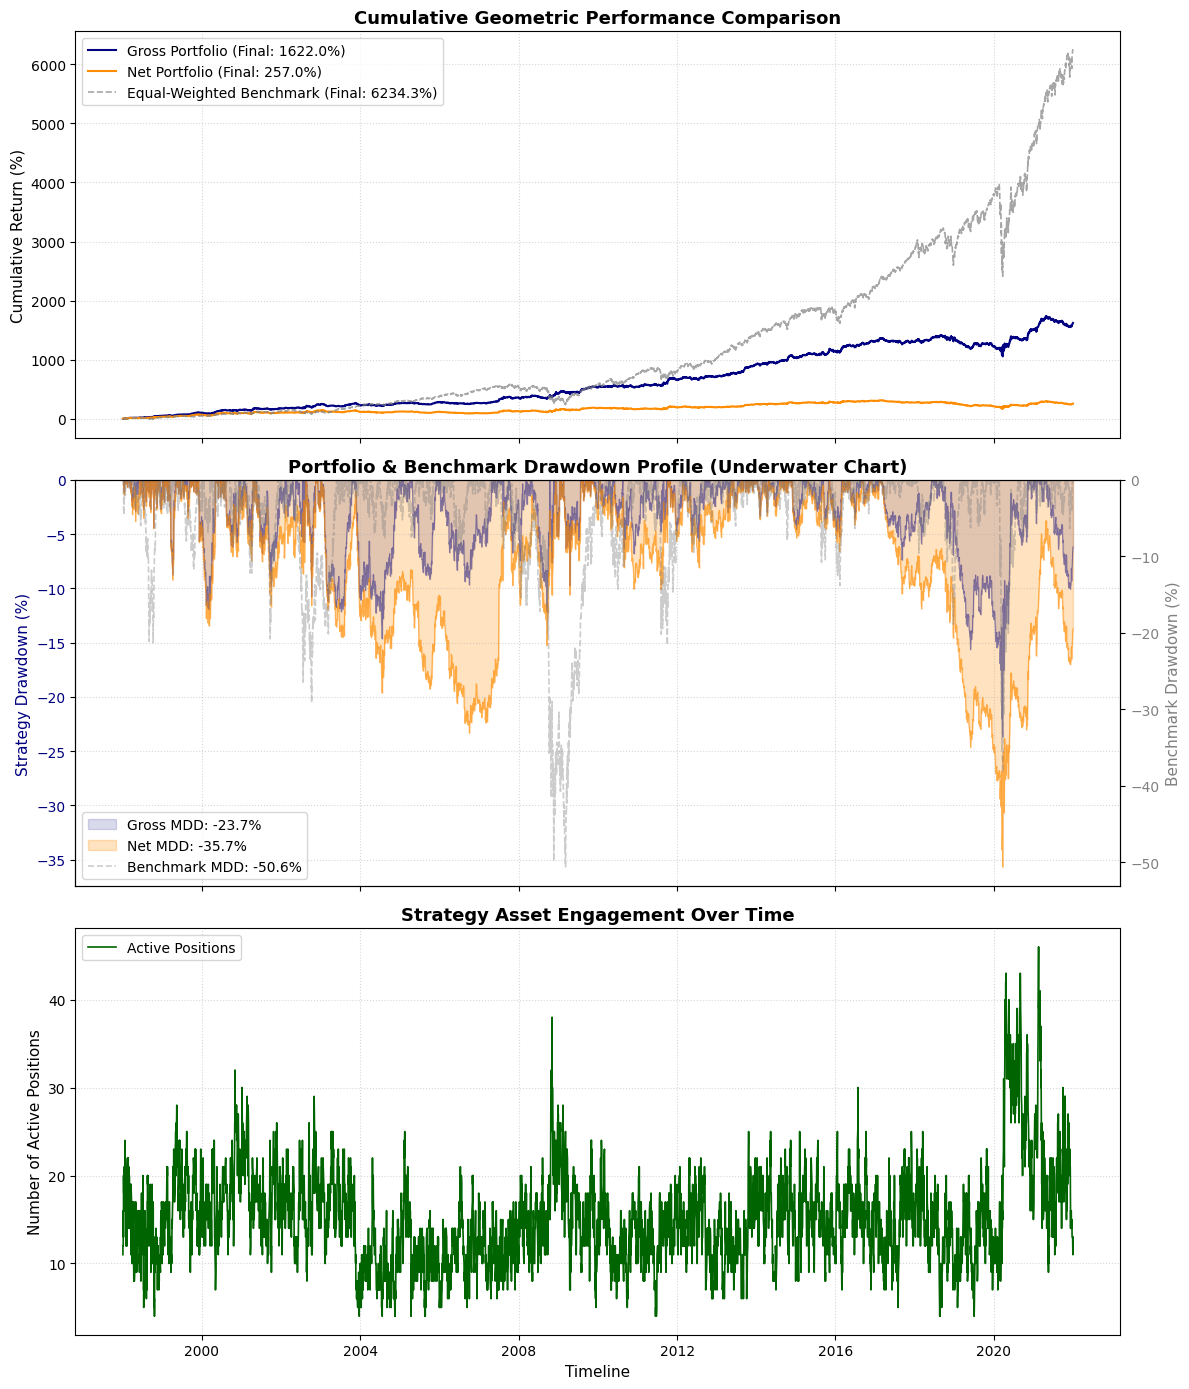

         INSTITUTIONAL PERFORMANCE SUMMARY       
Maximum Gross Drawdown:  -23.70%
Maximum Net Drawdown:    -35.66%
Maximum Bench Drawdown:  -50.61%
Terminal Net Return:     256.96%


In [5]:
# Generate and save the 3-panel dashboard
gross_dd, net_dd, benchmark_dd = generate_performance_dashboard(
    result=result,
    net_returns=result['net_returns'],
    benchmark_rets=benchmark_rets,
    save_path="optimal_k5_dashboard.png"
)

In [ ]:
# Run PCA/OU Model for Grid of K Values (saved printout in data folder)
metrics, results = train_pca_model(returns, mask, dates, eval_start_date,
                                   K_grid = [1, 3, 5, 8, 15, 30])